# **Import Library**

---

In [ ]:
!pip install numpy==1.26.4
!pip install scikit-learn==1.3.2
!pip install scikit-learn-extra==0.3.0

  Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.8 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
libpysal 4.14.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
imbalanced-learn 0.14.1 requires scikit-learn<2,>=1.4.2, bu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from statsmodels.stats.outliers_influence import variance_inflation_factor

# **LOAD DATA**

---

In [ ]:
df = pd.read_csv('Indikator_Kesejahteraan_Rakyat_Jatim (2).csv', sep=',', header=0)
df.dropna(how='all', inplace=True)
df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
wilayah = df["Kabupaten/Kota"]
X = df.drop(columns=["Kabupaten/Kota"])
print(df.head())

          Kabupaten/Kota  Jumlah Penduduk (Ribu)  Laju Pertumbuhan  \
0      Kabupaten Pacitan                   588.6              0.10   
1     Kabupaten Ponorogo                   962.9              0.36   
2   Kabupaten Trenggalek                   744.5              0.46   
3  Kabupaten Tulungagung                  1113.9              0.55   
4       Kabupaten Blitar                  1263.7              0.83   

   Rasio Beban Ketergantungan  Kepadatan Penduduk (km²)  \
0                       46.76                       411   
1                       45.41                       681   
2                       43.90                       598   
3                       42.99                       978   
4                       44.47                       730   

   Jumlah Tenaga Kesehatan  Fasilitas Kesehatan  Angka Kesakitan  \
0                      223                  221             8.53   
1                      392                  384             8.96   
2                   

**Cek Missing Value**

In [ ]:
df.isnull().sum()

,0
Kabupaten/Kota,0
Jumlah Penduduk (Ribu),0
Laju Pertumbuhan,0
Rasio Beban Ketergantungan,0
Kepadatan Penduduk (km²),0
Jumlah Tenaga Kesehatan,0
Fasilitas Kesehatan,0
Angka Kesakitan,0
Umur Harapan Hidup,0
Jaminan Kesehatan (PBI),0


# **Scaling**

---

In [ ]:
scaler = StandardScaler()
X_numeric = X.select_dtypes(include=np.number)
X_scaled = scaler.fit_transform(X_numeric)
X_scaled = pd.DataFrame(X_scaled, columns=X_numeric.columns)
display(X_scaled.head())

,Jumlah Penduduk (Ribu),Laju Pertumbuhan,Rasio Beban Ketergantungan,Kepadatan Penduduk (km²),Jumlah Tenaga Kesehatan,Fasilitas Kesehatan,Angka Kesakitan,Umur Harapan Hidup,Jaminan Kesehatan (PBI),Imunisasi Campak (%),...,Konsumsi/Pengeluaran,Penduduk Miskin (%),Indeks Kedalaman Kemiskinan,Indeks Keparahan Kemiskinan,Garis Kemiskinan,Sanitasi Layak,Sumber Penerangan PLN,Air Minum Layak,Rumah Layak Huni,Persentase Pengguna Internet Penduduk
0,-0.755077,-2.379604,1.985929,-0.687187,-0.669819,-0.674067,-0.547067,-0.148632,-0.804072,0.852800,...,-2.092437,0.793150,0.265236,-0.106661,-1.538970,-0.584785,0.186100,-3.047346,-0.762005,-0.685424
1,-0.202845,-1.424282,1.222797,-0.568173,0.224666,0.204177,-0.480198,0.654583,-0.656123,0.699781,...,-0.208736,-0.161719,-0.361367,-0.427700,-1.099560,0.499615,0.228245,-0.032518,1.139784,0.114141
2,-0.525066,-1.056850,0.369219,-0.604759,-0.473985,-0.517815,-0.688581,0.680082,-0.745173,1.302291,...,-2.092356,0.172606,0.185244,0.013729,-0.867862,-0.254216,0.160814,-3.018742,-0.653579,-0.175614
3,0.019937,-0.726161,-0.145189,-0.437257,0.425793,0.522069,0.519730,0.527089,-1.142744,0.197690,...,-0.228595,-0.842394,-0.921310,-0.708609,-0.731569,0.142243,0.101812,0.719759,0.878477,0.486542
4,0.240948,0.302648,0.691431,-0.546574,0.113517,0.355041,-0.026109,0.680082,-0.729046,1.448933,...,-0.212320,-0.390214,-0.654670,-0.628349,-1.214880,-0.068829,0.228245,0.479488,0.600907,0.685686


In [ ]:
display(X_scaled.head())

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31
0,-0.755077,-2.379604,1.985929,-0.687187,-0.669819,-0.674067,-0.547067,-0.148632,-0.804072,0.852800,...,-2.092437,0.793150,0.265236,-0.106661,-1.538970,-0.584785,0.186100,-3.047346,-0.762005,-0.685424
1,-0.202845,-1.424282,1.222797,-0.568173,0.224666,0.204177,-0.480198,0.654583,-0.656123,0.699781,...,-0.208736,-0.161719,-0.361367,-0.427700,-1.099560,0.499615,0.228245,-0.032518,1.139784,0.114141
2,-0.525066,-1.056850,0.369219,-0.604759,-0.473985,-0.517815,-0.688581,0.680082,-0.745173,1.302291,...,-2.092356,0.172606,0.185244,0.013729,-0.867862,-0.254216,0.160814,-3.018742,-0.653579,-0.175614
3,0.019937,-0.726161,-0.145189,-0.437257,0.425793,0.522069,0.519730,0.527089,-1.142744,0.197690,...,-0.228595,-0.842394,-0.921310,-0.708609,-0.731569,0.142243,0.101812,0.719759,0.878477,0.486542
4,0.240948,0.302648,0.691431,-0.546574,0.113517,0.355041,-0.026109,0.680082,-0.729046,1.448933,...,-0.212320,-0.390214,-0.654670,-0.628349,-1.214880,-0.068829,0.228245,0.479488,0.600907,0.685686


# **Uji Multikolinearitas (VIF)**

---

In [ ]:
vif_data = pd.DataFrame()
vif_data["Variabel"] = X_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i)
                   for i in range(X_scaled.shape[1])]
print(vif_data)

high_vif_vars = vif_data[vif_data["VIF"] > 10]["Variabel"].tolist()
safe_vars = vif_data[vif_data["VIF"] <= 10]["Variabel"].tolist()
print("\nVariabel VIF tinggi :", high_vif_vars)
print("Variabel aman:", safe_vars)

   Variabel         VIF
0        x1  200.163636
1        x2   15.565576
2        x3    7.147431
3        x4   34.306424
4        x5  198.350847
5        x6  521.965926
6        x7   10.453705
7        x8   26.323623
8        x9    8.139842
9       x10    5.887686
10      x11   13.491149
11      x12  206.871061
12      x13   63.212299
13      x14   12.794806
14      x15   27.448054
15      x16   16.908590
16      x17   13.875393
17      x18   16.531727
18      x19   22.552846
19      x20   14.979286
20      x21   12.467266
21      x22   30.826069
22      x23   68.367496
23      x24  505.962140
24      x25  416.743362
25      x26   19.222509
26      x27   22.124093
27      x28   30.583582
28      x29    7.004322
29      x30   22.495802
30      x31   42.490115

Variabel VIF tinggi : ['x1', 'x2', 'x4', 'x5', 'x6', 'x7', 'x8', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x30', 'x31']
Variabel aman: ['x3', 'x9'

# **PCA (Principal Component Analysis)**

---

Jumlah komponen PCA yang menjelaskan >= 80% variansi: 6


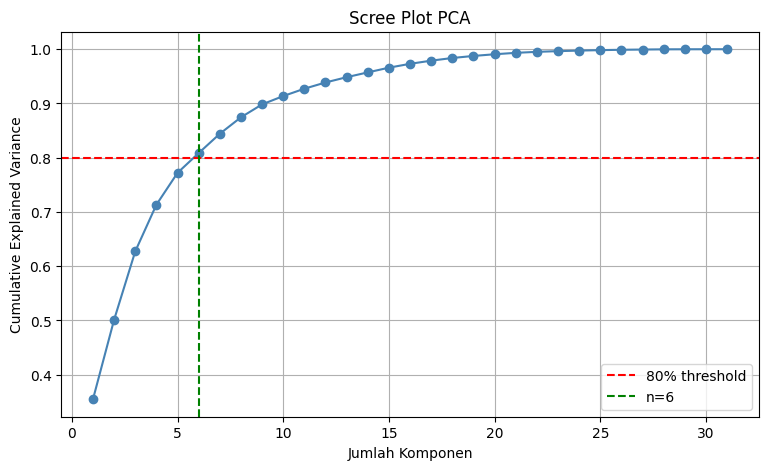

In [ ]:
X_for_pca = X_scaled.copy()

pca_full = PCA(random_state=42)
pca_full.fit(X_for_pca)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumvar >= 0.80) + 1
print(f'Jumlah komponen PCA yang menjelaskan >= 80% variansi: {n_components}')

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', color='steelblue')
plt.axhline(0.80, color='red', linestyle='--', label='80% threshold')
plt.axvline(n_components, color='green', linestyle='--', label=f'n={n_components}')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot PCA')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_for_pca)

pca_cols = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)
df_pca['Kabupaten/Kota'] = df['Kabupaten/Kota'].values

print(f'Shape data setelah PCA: {X_pca.shape}')
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {ev:.4f} ({ev*100:.2f}%)')
print(f'Total explained variance: {pca.explained_variance_ratio_.sum():.4f}')

X_for_clustering = df_pca[pca_cols].copy()

Shape data setelah PCA: (38, 6)
  PC1: 0.3548 (35.48%)
  PC2: 0.1466 (14.66%)
  PC3: 0.1260 (12.60%)
  PC4: 0.0860 (8.60%)
  PC5: 0.0587 (5.87%)
  PC6: 0.0365 (3.65%)
Total explained variance: 0.8086


In [ ]:
# Loading score - kontribusi variabel asli ke tiap PC
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(n_components)]
).round(3)

print("=== Loading Score PCA ===")
display(loadings)

# Variabel paling dominan per komponen (top 5)
for col in loadings.columns:
    top = loadings[col].abs().sort_values(ascending=False).head(5)
    print(f"\n{col} ({col} menjelaskan {pca.explained_variance_ratio_[int(col[2:])-1]*100:.2f}% variansi)")
    print(top)

=== Loading Score PCA ===


,PC1,PC2,PC3,PC4,PC5,PC6
Jumlah Penduduk (Ribu),-0.034,0.445,0.003,-0.038,0.123,-0.064
Laju Pertumbuhan,0.112,-0.047,0.205,0.057,-0.500,0.177
Rasio Beban Ketergantungan,-0.050,-0.278,-0.135,-0.201,0.215,-0.124
Kepadatan Penduduk (km²),0.232,-0.050,0.234,-0.066,0.133,0.143
Jumlah Tenaga Kesehatan,-0.058,0.401,-0.145,0.170,-0.021,-0.072
Fasilitas Kesehatan,-0.050,0.413,-0.160,0.126,-0.018,-0.111
Angka Kesakitan,-0.004,0.307,0.189,-0.137,0.244,0.114
Umur Harapan Hidup,0.238,0.027,-0.186,0.085,0.199,0.110
Jaminan Kesehatan (PBI),-0.020,-0.189,0.252,0.260,0.134,-0.158
Imunisasi Campak (%),0.118,0.005,-0.256,0.138,0.104,0.411



PC1 (PC1 menjelaskan 35.48% variansi)
Persentase Pengguna Internet Penduduk    0.291
Rata-rata Lama Sekolah (Thn)             0.290
Penduduk Miskin (%)                      0.267
AMH                                      0.264
Umur Harapan Hidup                       0.238
Name: PC1, dtype: float64

PC2 (PC2 menjelaskan 14.66% variansi)
Jumlah Penduduk (Ribu)     0.445
Fasilitas Kesehatan        0.413
Jumlah Tenaga Kesehatan    0.401
Angkatan Kerja             0.349
Angka Kesakitan            0.307
Name: PC2, dtype: float64

PC3 (PC3 menjelaskan 12.60% variansi)
Sarana Pendidikan           0.389
Garis Kemiskinan            0.287
Imunisasi Campak (%)        0.256
Jaminan Kesehatan (PBI)     0.252
Kepadatan Penduduk (km²)    0.234
Name: PC3, dtype: float64

PC4 (PC4 menjelaskan 8.60% variansi)
Indeks Keparahan Kemiskinan    0.440
Sumber Penerangan PLN          0.378
Indeks Kedalaman Kemiskinan    0.360
Jaminan Kesehatan (PBI)        0.260
Rumah Layak Huni               0.252
Name: PC4, d

# **Metode Elbow**

---

/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:252: UserWarning: n_clusters should be larger than 2 if max_iter != 0 setting max_iter to 0.
  warnings.warn(


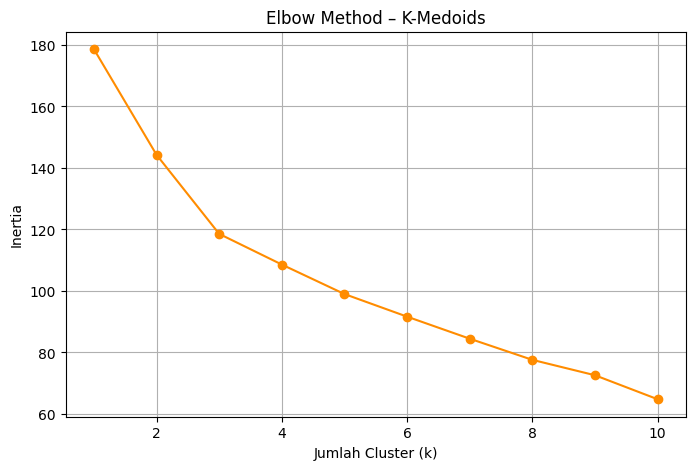

In [ ]:
k_range = range(1, 11)
inertia_kmed = []

for k in k_range:
    kmed_tmp = KMedoids(n_clusters=k, random_state=42, method='pam')
    kmed_tmp.fit(X_for_clustering)
    inertia_kmed.append(kmed_tmp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_kmed, marker='o', color='darkorange')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method – K-Medoids')
plt.grid(True)
plt.show()

# **Hierarchical Clustering**

---

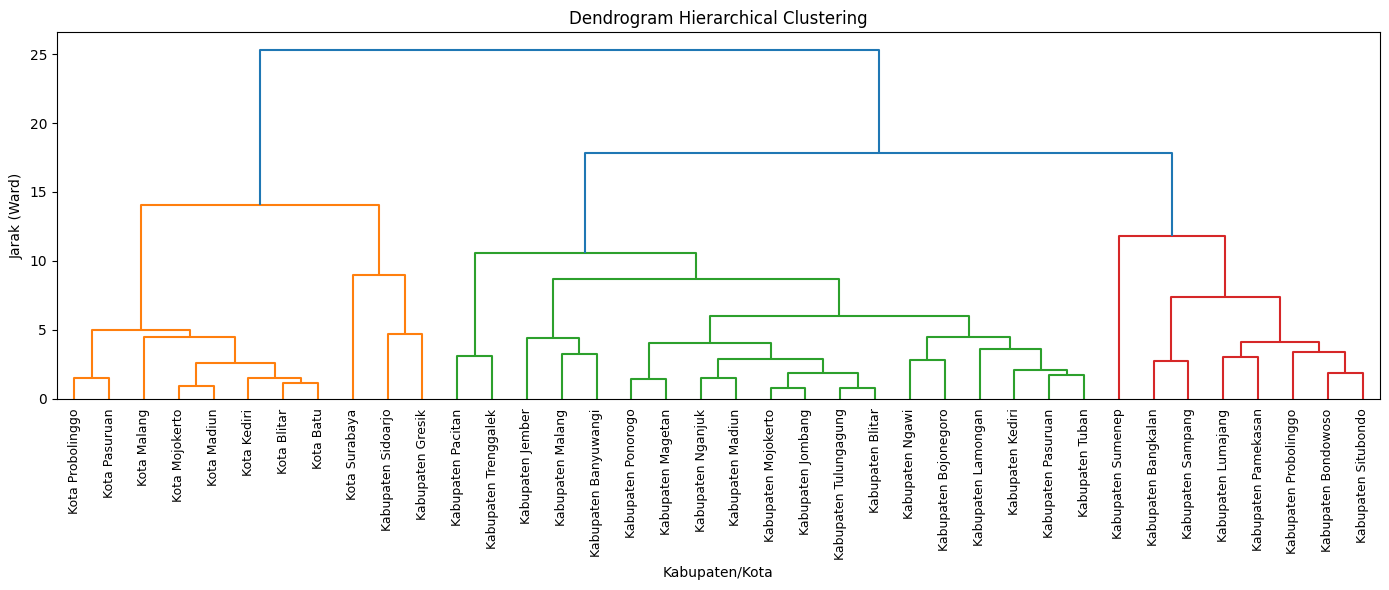

In [ ]:
Z = linkage(X_for_clustering, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, labels=df['Kabupaten/Kota'].values, leaf_rotation=90, leaf_font_size=9)
plt.title('Dendrogram Hierarchical Clustering')
plt.xlabel('Kabupaten/Kota')
plt.ylabel('Jarak (Ward)')
plt.tight_layout()
plt.show()

In [ ]:
k_hier = 3
cluster_hier_labels = fcluster(Z, k_hier, criterion='maxclust')

df_model = df_pca.copy()
df_model['cluster_hier'] = cluster_hier_labels

print('Jumlah wilayah per cluster (Hierarchical):')
print(df_model.groupby('cluster_hier')['Kabupaten/Kota'].count())

print('\nWilayah per cluster (Hierarchical):')
for c in sorted(df_model['cluster_hier'].unique()):
    print(f'\nCluster {c}:')
    print(df_model[df_model['cluster_hier'] == c]['Kabupaten/Kota'].tolist())

Jumlah wilayah per cluster (Hierarchical):
cluster_hier
1    11
2    19
3     8
Name: Kabupaten/Kota, dtype: int64

Wilayah per cluster (Hierarchical):

Cluster 1:
['Kabupaten Sidoarjo', 'Kabupaten Gresik', 'Kota Kediri', 'Kota Blitar', 'Kota Malang', 'Kota Probolinggo', 'Kota Pasuruan', 'Kota Mojokerto', 'Kota Madiun', 'Kota Surabaya', 'Kota Batu']

Cluster 2:
['Kabupaten Pacitan', 'Kabupaten Ponorogo', 'Kabupaten Trenggalek', 'Kabupaten Tulungagung', 'Kabupaten Blitar', 'Kabupaten Kediri', 'Kabupaten Malang', 'Kabupaten Jember', 'Kabupaten Banyuwangi', 'Kabupaten Pasuruan', 'Kabupaten Mojokerto', 'Kabupaten Jombang', 'Kabupaten Nganjuk', 'Kabupaten Madiun', 'Kabupaten Magetan', 'Kabupaten Ngawi', 'Kabupaten Bojonegoro', 'Kabupaten Tuban', 'Kabupaten Lamongan']

Cluster 3:
['Kabupaten Lumajang', 'Kabupaten Bondowoso', 'Kabupaten Situbondo', 'Kabupaten Probolinggo', 'Kabupaten Bangkalan', 'Kabupaten Sampang', 'Kabupaten Pamekasan', 'Kabupaten Sumenep']


**Rata-rata Variabel Asli per Cluster – Hierarchical**

In [ ]:
# Rata-rata variabel ASLI (sebelum scaling) per cluster
# Gunakan tabel ini sebagai dasar interpretasi karakteristik tiap cluster
df_hier_profile = df.copy()
df_hier_profile['Cluster'] = cluster_hier_labels

print("=== Rata-rata Variabel Asli per Cluster – Hierarchical Clustering ===\n")
cluster_mean_hier = df_hier_profile.groupby('Cluster')[X.columns].mean().round(2)
display(cluster_mean_hier)
print("\nCatatan: Interpretasi label cluster (tinggi/sedang/rendah) dilakukan")
print("secara manual berdasarkan nilai rata-rata variabel di atas.")

# Save the cluster_mean_hier DataFrame to an Excel file
output_filename_hier = 'rata_rata_hierarchical_per_cluster.xlsx'
cluster_mean_hier.to_excel(output_filename_hier, index=True)
print(f"\nHasil rata-rata variabel per cluster Hierarchical telah disimpan ke '{output_filename_hier}'")

=== Rata-rata Variabel Asli per Cluster – Hierarchical Clustering ===



,Jumlah Penduduk (Ribu),Laju Pertumbuhan,Rasio Beban Ketergantungan,Kepadatan Penduduk (km²),Jumlah Tenaga Kesehatan,Fasilitas Kesehatan,Angka Kesakitan,Umur Harapan Hidup,Jaminan Kesehatan (PBI),Imunisasi Campak (%),...,Konsumsi/Pengeluaran,Penduduk Miskin (%),Indeks Kedalaman Kemiskinan,Indeks Keparahan Kemiskinan,Garis Kemiskinan,Sanitasi Layak,Sumber Penerangan PLN,Air Minum Layak,Rumah Layak Huni,Persentase Pengguna Internet Penduduk
Cluster,,,,,,,,,,,,,,,,,,,,,
1,801.28,0.98,42.60,4902.00,230.91,227.45,12.24,75.72,59.36,77.90,...,1802438.09,5.59,0.80,0.17,661847.27,96.37,99.95,99.08,83.19,82.94
2,1316.83,0.60,43.60,805.00,434.58,440.42,11.45,75.23,48.98,77.57,...,1056155.84,10.02,1.24,0.25,473207.79,89.84,99.96,96.29,80.26,67.76
3,997.60,0.78,43.29,705.25,310.75,285.25,13.21,73.92,62.29,70.46,...,760710.92,14.99,2.09,0.49,499286.50,75.94,98.87,96.80,67.26,56.92



Catatan: Interpretasi label cluster (tinggi/sedang/rendah) dilakukan
secara manual berdasarkan nilai rata-rata variabel di atas.

Hasil rata-rata variabel per cluster Hierarchical telah disimpan ke 'rata_rata_hierarchical_per_cluster.xlsx'


**Silhouette Score – Hierarchical**

In [ ]:
score_hier = silhouette_score(X_for_clustering, df_model['cluster_hier'])
print(f'Silhouette Score (Hierarchical): {score_hier:.4f}')
print('Interpretasi: Nilai mendekati 1 = cluster sangat baik | mendekati 0 = terdapat tumpang tindih')

Silhouette Score (Hierarchical): 0.3353
Interpretasi: Nilai mendekati 1 = cluster sangat baik | mendekati 0 = terdapat tumpang tindih


# **Visualisasi Hierarchical Clustering**

---

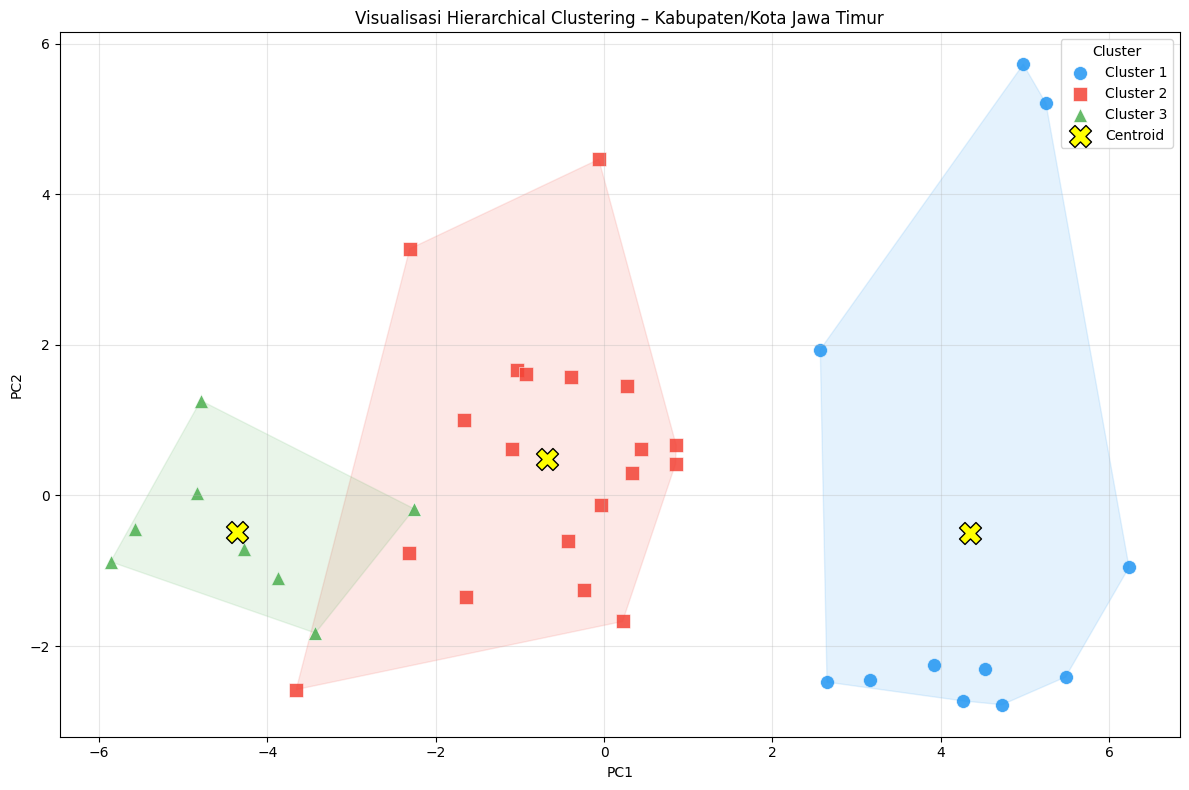

In [ ]:
from scipy.spatial import ConvexHull

X_vis = df_model[['PC1', 'PC2']].values
labels_hier = df_model['cluster_hier'].values

color_map_hier = {1: '#2196F3', 2: '#F44336', 3: '#4CAF50'}
marker_map_hier = {1: 'o', 2: 's', 3: '^'}

plt.figure(figsize=(12, 8))
for c in sorted(np.unique(labels_hier)):
    idx = labels_hier == c
    plt.scatter(X_vis[idx, 0], X_vis[idx, 1],
                c=color_map_hier[c], label=f'Cluster {c}',
                s=100, alpha=0.85, marker=marker_map_hier[c],
                edgecolors='white', linewidth=0.5)
    points = X_vis[idx]
    if len(points) >= 3:
        hull = ConvexHull(points)
        plt.fill(points[hull.vertices, 0], points[hull.vertices, 1],
                 color=color_map_hier[c], alpha=0.12)

centroids_hier = df_model.groupby('cluster_hier')[['PC1', 'PC2']].mean()
for c, row in centroids_hier.iterrows():
    plt.scatter(row['PC1'], row['PC2'],
                c='yellow', edgecolor='black', s=250, marker='X', zorder=5)
plt.scatter([], [], c='yellow', edgecolor='black', s=250, marker='X', label='Centroid')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualisasi Hierarchical Clustering – Kabupaten/Kota Jawa Timur')
plt.legend(title='Cluster', loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **K-Medoids Clustering**

---

In [ ]:
kmedoids = KMedoids(n_clusters=3, random_state=42, method='pam')
df_model['cluster_kmed'] = kmedoids.fit_predict(X_for_clustering)

# Seragamkan label jadi 1,2,3 (bukan 0,1,2)
df_model['cluster_kmed'] = df_model['cluster_kmed'] + 1

print('Jumlah wilayah per cluster (K-Medoids):')
print(df_model.groupby('cluster_kmed')['Kabupaten/Kota'].count())

print('\nWilayah per cluster (K-Medoids):')
for c in sorted(df_model['cluster_kmed'].unique()):
    print(f'\nCluster {c}:')
    print(df_model[df_model['cluster_kmed'] == c]['Kabupaten/Kota'].tolist())

Jumlah wilayah per cluster (K-Medoids):
cluster_kmed
1    21
2     8
3     9
Name: Kabupaten/Kota, dtype: int64

Wilayah per cluster (K-Medoids):

Cluster 1:
['Kabupaten Pacitan', 'Kabupaten Ponorogo', 'Kabupaten Trenggalek', 'Kabupaten Tulungagung', 'Kabupaten Blitar', 'Kabupaten Kediri', 'Kabupaten Malang', 'Kabupaten Lumajang', 'Kabupaten Banyuwangi', 'Kabupaten Pasuruan', 'Kabupaten Sidoarjo', 'Kabupaten Mojokerto', 'Kabupaten Jombang', 'Kabupaten Nganjuk', 'Kabupaten Madiun', 'Kabupaten Magetan', 'Kabupaten Ngawi', 'Kabupaten Bojonegoro', 'Kabupaten Tuban', 'Kabupaten Lamongan', 'Kabupaten Gresik']

Cluster 2:
['Kabupaten Jember', 'Kabupaten Bondowoso', 'Kabupaten Situbondo', 'Kabupaten Probolinggo', 'Kabupaten Bangkalan', 'Kabupaten Sampang', 'Kabupaten Pamekasan', 'Kabupaten Sumenep']

Cluster 3:
['Kota Kediri', 'Kota Blitar', 'Kota Malang', 'Kota Probolinggo', 'Kota Pasuruan', 'Kota Mojokerto', 'Kota Madiun', 'Kota Surabaya', 'Kota Batu']


**Rata-rata Variabel Asli per Cluster – K-Medoids**

In [ ]:
df_kmed_profile = df.copy()
df_kmed_profile['Cluster'] = df_model['cluster_kmed'].values

print("=== Rata-rata Variabel Asli per Cluster – K-Medoids Clustering ===\n")
cluster_mean_kmed = df_kmed_profile.groupby('Cluster')[X.columns].mean().round(2)
display(cluster_mean_kmed)
print("\nCatatan: Interpretasi label cluster (tinggi/sedang/rendah) dilakukan")
print("secara manual berdasarkan nilai rata-rata variabel di atas.")

# Save the cluster_mean_kmed DataFrame to an Excel file (without labeling)
output_filename = 'rata_rata_kmedoids_per_cluster.xlsx'
cluster_mean_kmed.to_excel(output_filename, index=True)
print(f"\nHasil rata-rata variabel per cluster K-Medoids telah disimpan ke '{output_filename}'")

=== Rata-rata Variabel Asli per Cluster – K-Medoids Clustering ===



,Jumlah Penduduk (Ribu),Laju Pertumbuhan,Rasio Beban Ketergantungan,Kepadatan Penduduk (km²),Jumlah Tenaga Kesehatan,Fasilitas Kesehatan,Angka Kesakitan,Umur Harapan Hidup,Jaminan Kesehatan (PBI),Imunisasi Campak (%),...,Konsumsi/Pengeluaran,Penduduk Miskin (%),Indeks Kedalaman Kemiskinan,Indeks Keparahan Kemiskinan,Garis Kemiskinan,Sanitasi Layak,Sumber Penerangan PLN,Air Minum Layak,Rumah Layak Huni,Persentase Pengguna Internet Penduduk
Cluster,,,,,,,,,,,,,,,,,,,,,
1,1290.35,0.64,43.27,917.67,453.90,452.00,11.13,75.28,48.63,77.98,...,1143268.86,9.75,1.24,0.25,485203.57,91.08,99.94,96.22,80.91,68.91
2,1179.84,0.79,43.16,724.00,326.50,307.50,14.95,73.87,62.45,70.45,...,740300.17,15.03,2.06,0.48,506128.75,74.69,98.94,97.24,67.04,57.39
3,586.51,0.97,43.27,5532.89,126.56,133.33,11.60,75.77,62.35,77.02,...,1783157.78,5.18,0.73,0.15,669695.00,96.05,99.94,99.47,82.51,83.23



Catatan: Interpretasi label cluster (tinggi/sedang/rendah) dilakukan
secara manual berdasarkan nilai rata-rata variabel di atas.

Hasil rata-rata variabel per cluster K-Medoids telah disimpan ke 'rata_rata_kmedoids_per_cluster.xlsx'


**Silhouette Score – K-Medoids**

In [ ]:
score_kmed = silhouette_score(X_for_clustering, df_model['cluster_kmed'])
print(f'Silhouette Score (K-Medoids): {score_kmed:.4f}')
print('Interpretasi: Nilai mendekati 1 = cluster sangat baik | mendekati 0 = terdapat tumpang tindih')

Silhouette Score (K-Medoids): 0.3608
Interpretasi: Nilai mendekati 1 = cluster sangat baik | mendekati 0 = terdapat tumpang tindih


# **Visualisasi K-Medoids Clustering**

---

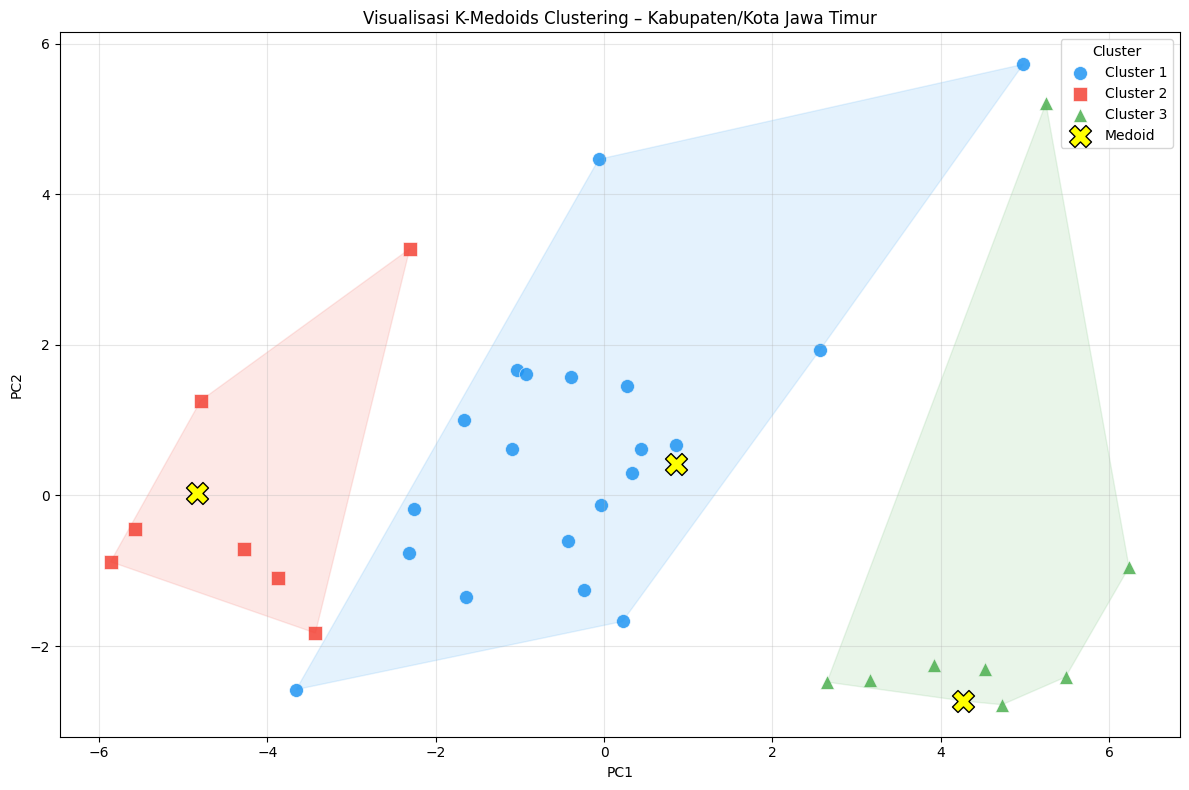

In [ ]:
from scipy.spatial import ConvexHull

X_vis_kmed = df_model[['PC1', 'PC2']].values
labels_kmed = df_model['cluster_kmed'].values

color_map_kmed = {1: '#2196F3', 2: '#F44336', 3: '#4CAF50'}
marker_map_kmed = {1: 'o', 2: 's', 3: '^'}

plt.figure(figsize=(12, 8))
for c in sorted(np.unique(labels_kmed)):
    idx = labels_kmed == c
    plt.scatter(X_vis_kmed[idx, 0], X_vis_kmed[idx, 1],
                c=color_map_kmed[c], label=f'Cluster {c}',
                s=100, alpha=0.85, marker=marker_map_kmed[c],
                edgecolors='white', linewidth=0.5)
    points = X_vis_kmed[idx]
    if len(points) >= 3:
        hull = ConvexHull(points)
        plt.fill(points[hull.vertices, 0], points[hull.vertices, 1],
                 color=color_map_kmed[c], alpha=0.12)

# Medoid indices dari fit asli (sebelum +1), pakai ulang kmedoids
medoid_pc = X_for_clustering.values[kmedoids.medoid_indices_, :2]
plt.scatter(medoid_pc[:, 0], medoid_pc[:, 1],
            c='yellow', edgecolor='black', s=250, marker='X', label='Medoid', zorder=5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualisasi K-Medoids Clustering – Kabupaten/Kota Jawa Timur')
plt.legend(title='Cluster', loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Perbandingan Silhouette Score – Hierarchical vs K-Medoids**

---

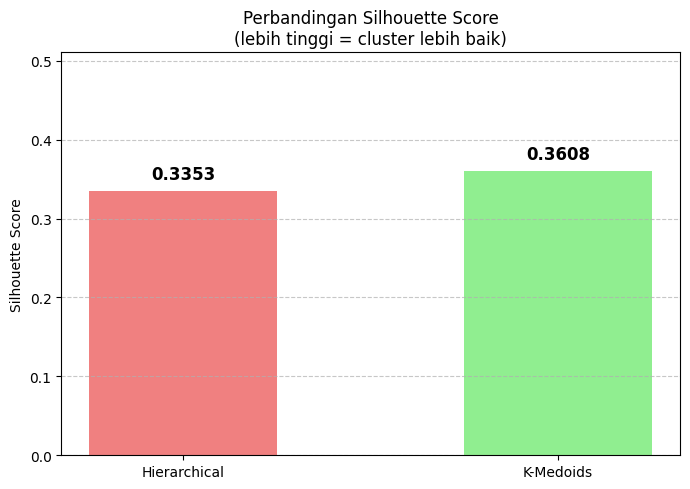


=== Ringkasan Evaluasi ===
   Algoritma Silhouette Score
Hierarchical           0.3353
   K-Medoids           0.3608

Algoritma terbaik berdasarkan Silhouette Score: K-Medoids


In [ ]:
algorithms = ['Hierarchical', 'K-Medoids']
silhouette_all = [score_hier, score_kmed]

plt.figure(figsize=(7, 5))
bars = plt.bar(algorithms, silhouette_all, color=['lightcoral', 'lightgreen'], width=0.5)
plt.ylabel('Silhouette Score')
plt.title('Perbandingan Silhouette Score\n(lebih tinggi = cluster lebih baik)')
plt.ylim(0, max(silhouette_all) + 0.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, v in zip(bars, silhouette_all):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n=== Ringkasan Evaluasi ===")
comparison_df = pd.DataFrame({
    'Algoritma': algorithms,
    'Silhouette Score': [f'{v:.4f}' for v in silhouette_all]
})
print(comparison_df.to_string(index=False))

best = algorithms[int(np.argmax(silhouette_all))]
print(f"\nAlgoritma terbaik berdasarkan Silhouette Score: {best}")